In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scipy
from scipy import signal as signal
from numpy.fft import fft, fftfreq, fftshift, ifft
from scipy.signal import firwin, freqz
pi = np.pi

import IPython
from scipy.io.wavfile import read

In [ ]:
data = read('/content/drive/MyDrive/45945.wav')
print(data)
#El primero es la frecuencia de muestreo, el segundo es el arreglo de datos del audio

(23552, array([ 13122,  13068,   7308, ...,  -3061, -10445,   7522], dtype=int16))


In [ ]:
fs = data[0]
audio = data[1]

In [ ]:
t=np.arange(0,len(audio),1/fs)

In [ ]:
plt.plot(t,audio) #Aquí se encuentra en muestras, no en tiempo (para crear el vector de tiempo se necesita la frecuencia de muestreo)
plt.title('Audio original')
plt.xlabel('Muestras', color = 'r')
plt.show()

In [ ]:
IPython.display.Audio(audio, rate=fs) #Reproduce el audio

In [ ]:
Ts = 1 / fs
t = np.linspace(0, 10 + Ts, len(audio))
x_jΩ = fft(audio)
N = len(t)
Ω = fftfreq(N, Ts)

Ω_ordenada = fftshift(Ω)
x_jΩ_ordenada = fftshift(x_jΩ)

#Crear una figura donde se puedan observar una grafica y una imagen para comparar donde se encuentran los posibles números que fueron presionados
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].plot(Ω_ordenada,abs(x_jΩ_ordenada)*2*pi/N, color = 'mediumorchid')
axs[0].set_title('Espectro de la señal ordenada')
axs[0].set_xlabel('Frecuencia Hz')
axs[0].set_ylabel('|X(jΩ)|')
axs[0].set_xlim(0, 1750)
axs[0].grid()

img = mpimg.imread('/content/drive/MyDrive/Ref.png')#Ruta de la imagen
axs[1].imshow(img)
axs[1].axis('off')  # Quitar ejes

plt.tight_layout()
plt.show()

## Gracias a la imagen se pueden observar cuales son los posibles números que pueden ser presionados: las dos primeras frecuencias corresponden a las filas de los números del 4-6 y del 7-9, y las últimas 3 frecuencias corresponden a las columnas.

# **Posibles números: 4-5-6-7-8-9**

# Frecuencias de interes: 770, 852, 1209, 1336, 1477Hz son los picos que se observan en la gráfica de arriba



---


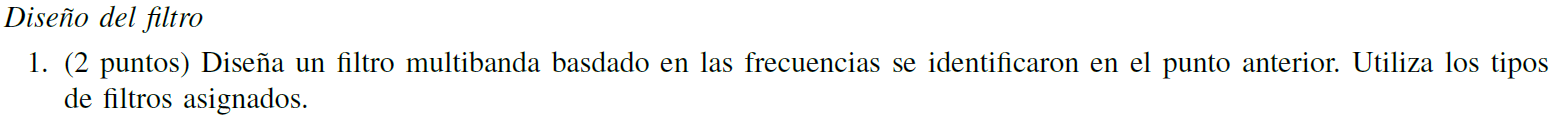

In [ ]:
#Entre mayor sea la longitud es más rapida la transición entre la banda de paso y de rechazo
M = 7501 #Siempre impar para no tener problemas con el logaritmo

#Reducir mucho la banda de paso para evitar pasar ruido
h_hamm1 = signal.firwin(M, [770 - 1/(2*fs), 770 + 1/(2*fs)], window = 'hamming', pass_zero = 'bandpass', fs = fs) #Esto ya es causal
h_han2 = signal.firwin(M, [852 - 1/(2*fs), 852 + 1/(2*fs)], window = 'han', pass_zero = 'bandpass', fs = fs) #pass_zero define el tipo de filtro utilizado
h_hamm3 = signal.firwin(M, [1209 - 1/(2*fs), 1209 + 1/(2*fs)], window = 'hamming', pass_zero = 'bandpass', fs = fs)
h_han4 = signal.firwin(M, [1336 - 1/(2*fs), 1336 + 1/(2*fs)], window = 'han', pass_zero = 'bandpass', fs = fs)
h_hamm5 = signal.firwin(M, [1477 - 1/(2*fs), 1477 + 1/(2*fs)], window = 'hamming', pass_zero = 'bandpass', fs = fs)

h_band = h_hamm1 + h_han2 + h_hamm3 + h_han4 + h_hamm5 #Filtro pasabanda

#La banda de rechazo debe estar a la inversa que el pasabanda pero haciendo que las frecuenciencias de interes coincidan (multiplicar todo por 2/fs)
h_r1 = signal.firwin(M, [1/fs, (770 - 1/(2*fs))*2/fs], window = 'hamming', pass_zero = 'bandstop', fs = fs) #Esto ya es causal
h_r2 = signal.firwin(M, [(770 + 1/(2*fs))*2/fs, (852 - 1/(2*fs))*2/fs], window = 'han', pass_zero = 'bandstop', fs = fs) #pass_zero define el tipo de filtro utilizado
h_r3 = signal.firwin(M, [(852 + 1/(2*fs))*2/fs, (1209 - 1/(2*fs))*(2/fs)], window = 'hamming', pass_zero = 'bandstop', fs = fs)
h_r4 = signal.firwin(M, [(1209 + 1/(2*fs))*(2/fs), (1336 - 1/(2*fs))*(2/fs)], window = 'han', pass_zero = 'bandstop', fs = fs)
h_r5 = signal.firwin(M, [(1336 + 1/(2*fs))*(2/fs), (1477 - 1/(2*fs))*(2/fs)], window = 'hamming', pass_zero = 'bandstop', fs = fs)
h_r6 = signal.firwin(M, [(1477 + 1/(2*fs))*(2/fs), (fs/2)*2/fs], window = 'hamming', pass_zero = 'bandstop', fs = fs)

h_rec = h_r1 + h_r2 + h_r3 + h_r4 + h_r5 + h_r6 #Filtro rechaza banda

h = np.convolve(h_band, h_rec) #Filtro final

w, H = signal.freqz(h, fs=fs) #0 a fs/2 (freq de nyquist), si eliminamos la fs el eje x va a estar hasta pi
plt.plot(w, 20 * np.log10(np.abs(H)))
plt.title("Respuesta en frecuencia")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud (dB)")
#plt.xlim(0, 2000)
plt.grid()
plt.show()

In [ ]:
audio_filtrado = np.convolve(audio, h)
t = np.arange(0,len(audio_filtrado)/fs,1/fs)
plt.plot(t, audio_filtrado, color = 'cyan')
plt.title("Audio filtrado", color = 'indianred')
plt.xlabel('Tiempo (s)', color = 'r')
plt.show()



---



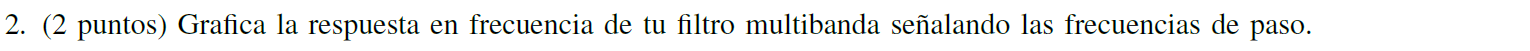

In [ ]:
w, H = signal.freqz(h, worN=2048, fs=fs) #worN cuantos puntos se usan para calcular la respuesta en frecuencia
plt.figure(figsize=(14, 4))
plt.plot(w, 20 * np.log10(np.abs(H)))
plt.axvline(770, color = 'r')
plt.axvline(852, color = 'purple')
plt.axvline(1209, color = 'green')
plt.axvline(1336, color = 'orange')
plt.axvline(1477, color = 'black')

plt.title("Respuesta en frecuencia")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud (dB)")
plt.xlim(0, 2000)
plt.grid()
plt.show()



---



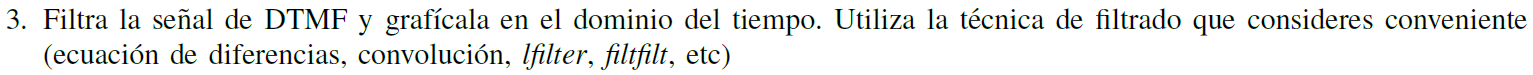

In [ ]:
plt.figure(figsize = (14, 4))
plt.subplot(1, 2, 1)
plt.plot(audio, color = 'lightpink') #Aquí se encuentra en muestras, no en tiempo (para crear el vector de tiempo se necesita la frecuencia de muestreo)
plt.title('Audio original', color = 'indianred')
plt.axvline(0.5*fs, color = 'deeppink')
plt.axvline(1.15*fs, color = 'deeppink')
plt.axvline(1.78*fs, color = 'deeppink')
plt.axvline(2.38*fs, color = 'deeppink')
plt.xlabel('Muestras', color = 'r')

audio_filtrado = np.convolve(audio, h)
t = np.arange(0,len(audio_filtrado)/fs,1/fs)
plt.subplot(1, 2, 2)
plt.plot(t, audio_filtrado, color = 'cyan')
plt.axvline(0.8, color = 'deeppink')
plt.axvline(1.45, color = 'deeppink')
plt.axvline(2.05, color = 'deeppink')
plt.axvline(2.7, color = 'deeppink')
plt.xlabel('Tiempo (s)', color = 'r')
plt.title('Audio filtrado', color = 'indianred')
plt.show()



---



### Se puede observar que sí filtró mucho ruido intermedio entre cada frecuencia de interes

Observar donde coinciden las frecuencias de corte: el número donde se une la frecuencia que indica la fila y la que indica la columna.



---



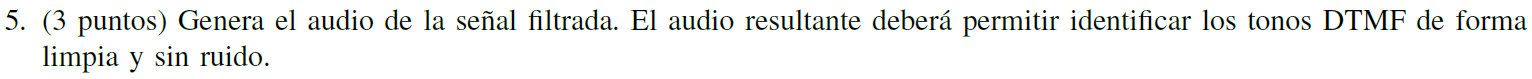

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
